In [ ]:
# Full name
NAME = ""
# Institutional email (hm.edu or hmtm.de)
EMAIL = ""

<a href="https://colab.research.google.com/github/aica-wavelab/aica-assignments/blob/main/A2_generation/8_autoencoder.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Rudiments of Machine Learning: Learning a Continuous Function

+ **AI in Culture and Arts - Tech Crash Course**
+ **Date:** 20.05.2026
+ **Authors:** [Dr. Benedikt Zönnchen](https://bzoennchen.github.io/Pages/)

In [ ]:
#@title Setup: install required Python packages

# install packages
%pip install numpy
%pip install torch
%pip install torchvision
%pip install torchinfo
%pip install torchview
%pip install matplotlib
%pip install seaborn
%pip install otter-grader==5.5.0

In [ ]:
#@title Setup: download assignment files (run this cell)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # download test files
    import os, requests

    folders = ['tests', 'figs', 'models']
    link = "https://api.github.com/repos/aica-wavelab/aica-assignments/contents/A2_generation"

    def download(entry, dest):
        if entry.get('type') != 'file' or not entry.get('download_url'):
            return
        r = requests.get(entry['download_url'])
        r.raise_for_status()
        with open(dest, 'wb') as out:
            out.write(r.content)

    for folder in folders:
        os.makedirs(folder, exist_ok=True)
        for f in requests.get(f"{link}/{folder}").json():
            download(f, f"{folder}/{f['name']}")

    for f in requests.get(link).json():
        if f['name'].endswith('.py'):
            download(f, f['name'])

## 17 Autoencoder

An [Autoencoder](https://en.wikipedia.org/wiki/Autoencoder) consists of two main components: an *encoder* and a *decoder*. The encoder takes an image (or some other data) as input and compresses it into a code or latent embedding. This embedding serves as a compact representation of the input's most essential features. This "bottleneck" is then passed to the decoder, whose task is to reconstruct the original input as accurately as possible.

**Compression and Representation:** The fundamental goal of an autoencoder is dimensionality reduction. By forcing the data through a latent space, which typically has much fewer dimensions than the original image, the network must learn to discard noise and retain only the most relevant information. Because the network learns this optimal encoding automatically through machine learning, it is called an *autoencoder*.

**Self-Supervised Learning:** Autoencoders are trained by presenting the same image as both the input and the target output. When trained on a large dataset, the model learns the underlying structure and statistics of the data.

As you may have noticed, this is a prime example of *self-supervised learning*. Unlike traditional classification networks, autoencoders do not require manually annotated labels. They simply use the data itself as the "teacher signal".

**Generative Potential:** Beyond simple compression, the training process forces the decoder to "understand" the inherent geometry of the data. Once trained, the decoder can be used independently to generate new images by sampling points from the latent space.

In the following section, we will use the classic MNIST dataset to explore how an autoencoder functions in practice.

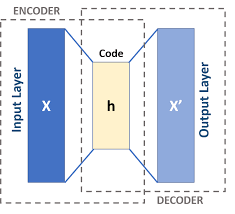


### 17.1 Data Collection - Loading the MNIST Dataset

Many of the following steps will already be familiar to you. We begin by importing the necessary libraries and downloading the MNIST dataset using `torchvision`.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

In [ ]:
import torch

# Checking if a GPU (CUDA) is available and counting them
gpu_count = torch.cuda.device_count()
print(f"Anzahl der zugewiesenen GPUs: {gpu_count}")

# Extra tip: Check the name of the GPU you're working with
if gpu_count > 0:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

In [ ]:
# Download the training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True)

# To see the shape (similar to train_images.shape)
# We access the underlying data attribute
print(f"Shape of train_images: {train_dataset.data.shape}")

In [ ]:
# Unsqueeze(1) turns (60000, 28, 28) into (60000, 1, 28, 28)
train_images_01 = train_dataset.data.unsqueeze(1).float() / 255.0
test_images_01 = test_dataset.data.unsqueeze(1).float() / 255.0

print(f"Shape of train_images_01: {train_images_01.shape}")

### 17.2 Model Definition - Encoder and Decoder

As previously mentioned, the *autoencoder* consists of an *encoder* and a *decoder*, which we implement here as separate components. In technical jargon, the embedding, that is, the layer representing the output of the encoder and the input of the decoder, is often called a *latent variable*. It is considered "latent" because it exists "beneath the surface" of the raw data and is **not directly observable**.

#### 17.2.1 Encoder Definition

We must define a dimensionality for our latent variable, which determines the number of elements (units) the embedding will contain. While MNIST digits have a resolution of 28x28 pixels, the actual information within the images is largely limited to one of ten digits. Consequently, we can assume that this information can be significantly compressed. We will therefore choose an embedding with eight dimensions.

In [ ]:
latent_dim = 8

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            # Input: (Batch, 1, 28, 28)
            # Conv2D(in_channels, out_channels, kernel_size, stride)
            nn.Conv2d(1, 32, kernel_size=3, stride=2),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2),
            nn.ReLU(),
            
            nn.Flatten(),
            # We need to calculate the input features for the Dense (Linear) layer.
            # After two Conv layers with stride 2, a 28x28 image becomes 6x6.
            # 64 filters * 6 * 6 = 2304
            nn.Linear(64 * 6 * 6, latent_dim)
        )

    def forward(self, x):
        return self.encoder(x)

encoder = Encoder(latent_dim)
print(encoder)

#### 17.2.2 Decoder Definition

The decoder's task is to transform the eight dimensions of the encoder's output layer back into a $28 \times 28$ pixel image. We can, therefore, think of the decoder as a sort of "inverted" encoder. To achieve this, we can use the `nn.ConvTranspose2d` class, which implements the inverse operation of a standard convolutional layer.

---

🗣 **Hint:** While `nn.ConvTranspose2d` is often called a "deconvolution," it is important to remember that it doesn't mathematically "undo" the convolution in the sense of finding the exact original pixels. Instead, it upsamples the feature maps and learns the best weights to reconstruct the spatial structure.

---

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        # Dense layer to get back to a spatial volume
        self.fc = nn.Linear(latent_dim, 7 * 7 * 32)
        
        self.decoder = nn.Sequential(
            # Conv2DTranspose(in_channels, out_channels, kernel_size, stride, padding)
            # Starting from (Batch, 32, 7, 7)
            nn.ConvTranspose2d(32, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Result: (Batch, 64, 14, 14)
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Result: (Batch, 32, 28, 28)
            
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
            # Final Result: (Batch, 1, 28, 28)
        )

    def forward(self, x):
        x = self.fc(x)
        x = torch.relu(x)
        # Reshape: (Batch, Channels, Height, Width)
        x = x.view(-1, 32, 7, 7) 
        return self.decoder(x)

decoder = Decoder(latent_dim)
print(decoder)

#### 17.2.3 Autoencoder Definition

We can now connect the two networks by creating a model where the input is the input of the *encoder*, and the output is the output of the *decoder* after the decoder has been fed the encoder's output (the embedding) as its own input.

In [ ]:
# 1. Define the full Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        # This is the PyTorch version of 'outputs=decoder(encoder.output)'
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

# Initialize the model
autoencoder = Autoencoder(encoder, decoder)

# 2. Define the Optimizer (equivalent to optimizer='adam')
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

# 3. Define the Loss Function (equivalent to loss='binary_crossentropy')
# BCELoss requires the input and target to be in the range [0, 1]
criterion = nn.BCELoss()

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.to(device)

print(autoencoder)

In [ ]:
from torchinfo import summary
summary(autoencoder)

We can also visualize the network:

In [ ]:
from torchview import draw_graph

dummy_input = torch.randn(1, 1, 28, 28).to(device)

with torch.no_grad():
  model_graph = draw_graph(autoencoder, input_data=dummy_input)
model_graph.visual_graph

### 17.3 Model Evaluation before Training

Our untrained model is so far filled only with random numbers and therefore generates a 28x28 ant war from the input images.

In [ ]:
n_plot = 10

# 1. Set the model to evaluation mode
autoencoder.eval()

# 2. Perform inference without tracking gradients
with torch.no_grad():
    # Move data to the same device as the model (e.g., GPU)
    # We take the first few images for plotting
    input_data = test_images_01[:n_plot].to(device)
    
    # Forward pass: the equivalent of autoencoder.predict()
    reconstructed_data = autoencoder(input_data)
    
    # Move back to CPU and convert to numpy for plotting
    # We also remove the channel dimension with .squeeze()
    decoded_imgs = reconstructed_data.cpu().numpy()

# 3. Plotting
plt.figure(figsize=(20, 4))

for i in range(n_plot):
    # Display original
    ax = plt.subplot(2, n_plot, i + 1)
    # PyTorch is (Batch, C, H, W), so we squeeze out the channel to get (28, 28)
    plt.imshow(test_images_01[i].squeeze().numpy(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n_plot, i + 1 + n_plot)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

### 17.4 Training

We now train the autoencoder using the digit images. Note that `x` and `y` in the `fit` function are the *same* variable, serving as both the training data *and* the desired output, since the autoencoder is supposed to reconstruct them.

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# 1. Prepare DataLoaders (Equivalent to batch_size and shuffle)
train_ds = TensorDataset(train_images_01, train_images_01)
test_ds = TensorDataset(test_images_01, test_images_01)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

# 2. Training Loop
epochs = 40

for epoch in range(epochs):
    autoencoder.train() # Set to training mode
    train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        # Move data to GPU
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = autoencoder(batch_x)
        loss = criterion(outputs, batch_y)
        
        # Backward pass (Backpropagation)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        train_loss += loss.item() * batch_x.size(0)
    
    # 3. Validation Logic (Equivalent to validation_data)
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_x, val_y in test_loader:
            val_x, val_y = val_x.to(device), val_y.to(device)
            val_outputs = autoencoder(val_x)
            v_loss = criterion(val_outputs, val_y)
            val_loss += v_loss.item() * val_x.size(0)
            
    # Print progress
    avg_train = train_loss / len(train_loader.dataset)
    avg_val = val_loss / len(test_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_train:.4f} - Val Loss: {avg_val:.4f}")

### 17.5 Save a Models (optional)

In [ ]:
torch.save(encoder.state_dict(), "models/encoder_model.pt")
torch.save(decoder.state_dict(), "models/decoder_model.pt")

### 17.6 Load a Models (optional)

In [ ]:
# 1) Modell mit identischer Architektur neu anlegen
encoder = Encoder(latent_dim)
decoder = Decoder(latent_dim)

# 2) Gewichte einladen
encoder.load_state_dict(torch.load("models/encoder_model.pt", map_location=device))
encoder.to(device)
decoder.load_state_dict(torch.load("models/decoder_model.pt", map_location=device))
decoder.to(device)

autoencoder = Autoencoder(encoder, decoder)
autoencoder.to(device)

# 3) In Inferenz-Modus schalten (schaltet Dropout aus, BN auf running stats)
encoder.eval()
decoder.eval()

### 17.7 Model Evaluation after Training

Now we can have the network generate output for the test data again.

In [ ]:
# 1. Prepare for inference
encoder.eval()
decoder.eval()

n = 10

with torch.no_grad():
    # Move data to device (GPU/CPU)
    input_batch = test_images_01[:n].to(device)
    
    # Forward passes (equivalent to .predict)
    encoded_tensors = encoder(input_batch)
    decoded_tensors = decoder(encoded_tensors)
    
    # Move back to CPU and convert to NumPy for Matplotlib
    encoded_imgs = encoded_tensors.cpu().numpy()
    de_encoded_imgs = decoded_tensors.cpu().numpy()

# 2. Plotting
n = 10
plt.figure(figsize=(30, 8))
for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)
    # PyTorch is (1, 28, 28), so we squeeze or reshape
    plt.imshow(test_images_01[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Display latent representation (the "encoding")
    ax = plt.subplot(3, n, n + i + 1)
    # Reshaping 8 dimensions into (4, 2) or whatever (-1, 2) results in
    plt.imshow(encoded_imgs[i].reshape(-1, 2), cmap=plt.cm.Spectral, vmin=-10, vmax=10)
    plt.xlim((-5, 9))
    plt.ylim((-5, 9))
    plt.axis('off')

    # Display reconstruction
    ax = plt.subplot(3, n, 2 * n + i + 1)
    plt.imshow(de_encoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

As we can see, the model produces digits that are very similar to the input. In the middle of the visualization, you can see the corresponding *code* for each. It is important to keep in mind that all information in the autoencoder must flow through this *bottleneck*. This means the output images are generated from the eight-digit code and not from the input image.

<!-- BEGIN QUESTION -->

---

🖍 **Exercise 17.1:**  Experiment with the size of the embedding. What do you observe when it is, for example, only 2-dimensional?

---

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### 17.8 The Decoder as a Generative Model

Since the decoder works solely on the basis of the *latent variable*, we can also use it in isolation. We can generate corresponding images from *embeddings* with arbitrary values.

Let's first try a random embedding:

In [ ]:
# 1. Generate the random encoding in NumPy (as in your snippet)
# latent_dim is 8
random_encoding = (np.random.rand(latent_dim) - 0.5) * 10

# 2. Convert to PyTorch Tensor and add batch dimension (np.newaxis equivalent)
# Then move to the device (GPU/CPU)
encoding_tensor = torch.from_numpy(random_encoding).float().unsqueeze(0).to(device)

# 3. Inference
decoder.eval()
with torch.no_grad():
    # Pass through decoder
    generated_tensor = decoder(encoding_tensor)
    # Move back to CPU and convert to NumPy for plotting
    random_img = generated_tensor.cpu().numpy().reshape(28, 28)

# 4. Plotting (identical logic to yours)
plt.figure(figsize=(5, 10))
plt.subplot(2, 1, 1)
# Visualizing the 8-dim vector as a 4x2 grid
plt.imshow(random_encoding.reshape((4, 2)), cmap=plt.cm.Spectral, vmin=-10, vmax=10)
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(random_img, cmap='gray')
_ = plt.axis('off')

The *latent space* — that is, all possible combinations of numbers that the embedding can cover — is enormous, and only in certain regions have *clusters* formed through training, in which the individual digits are represented. However, we see that even a randomly chosen code produces a structure that has the basic form of a handwritten digit.

We can also deliberately select a point in the embedding space by starting from the embedding of a real number. If we then choose a random direction of change and add it to the code with increasingly larger weights, the decoded image initially still looks like the original number. But the further we move away from the original code, the more our number disappears.

In [ ]:
# 1. Get the initial code for the first test image
# Use [None, ...] to add the batch dimension, then move to device
input_img = test_images_01[0:1].to(device) 

encoder.eval()
decoder.eval()

with torch.no_grad():
    code = encoder(input_img) # This is already a tensor on 'device'
    
    # 2. Create the random direction (on the same device and same shape as code)
    # torch.randn_like is a handy way to match shape/type/device
    direction = torch.randn_like(code)
    
    displacements = [0, .5, 1, 1.5, 2, 2.5, 3]
    plt.figure(figsize=(12, 10))
    
    for i, d in enumerate(displacements):
        plt.subplot(1, len(displacements), i + 1)
        
        # 3. Arithmetic: code + direction * d
        # This happens on the GPU (if available)
        new_code = code + (direction * d)
        
        # Generate and move back to CPU for plotting
        img = decoder(new_code).cpu().squeeze()
        
        plt.imshow(img.numpy(), cmap='gray')
        plt.title(f"d={d}")
        plt.axis('off')

plt.show()

So with our code, we are dealing with a *continuous* space in which every point gives us a result, and points lying close to one another produce similar images.

For example, we can also generate a *morphing* between two numbers by moving through the code space from one number to the next and generating several images along the way:

<!-- BEGIN QUESTION -->

---

🖍 **Exercise 17.2:** Try to morph one number into the other!

- Start with 2 different images and form the embeddings
- For each, compute the weighted average of these embeddings `morphed = (1-alpha) * encoded_imgs[start_img_number] + alpha * encoded_imgs[end_img_number]` for various values of `alpha = 0 to 1`
- Visualize the result when you decode these "new" embeddings

---

In [ ]:
...

<!-- END QUESTION -->

